<a target="_blank" href="https://colab.research.google.com/github/Datacompintensive/HS-25-26/blob/master/GoodFeaturesToTrack/optical_flow_test.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount('/content/drive/')
    %cd /content/drive/My Drive/HS-25-26
except:
    IN_COLAB = False
    # Updating imports
    %load_ext autoreload
    %autoreload 2
print(f'Running on {"Google colab" if IN_COLAB else "Local computer"}')

Mounted at /content/drive/
/content/drive/.shortcut-targets-by-id/1qPdwNZgQABzlqxdDvljTIb5wxHRtCM7g/HS-25-26
Running on Google colab


In [2]:
import os
import numpy as np
import cv2
from matplotlib import pyplot as plt
import torch
import torchvision
import torch.nn.functional as F
import PIL.Image
import time

if IN_COLAB:
    data_dir = "img/GoodFeaturesToTrack"
else:
    data_dir = "img"

if not os.path.exists(data_dir):
    raise FileNotFoundError(f"Directory not found: {data_dir}")


Text(0.5, 1.0, '(b) Features')

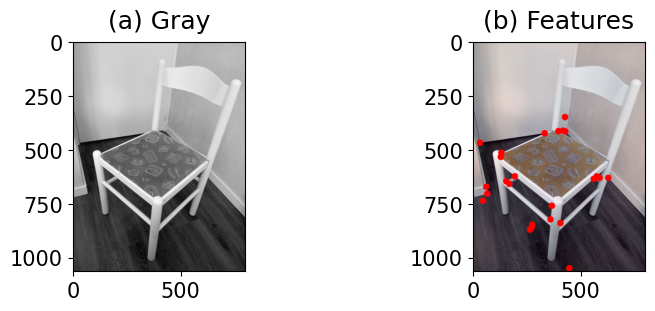

In [3]:
plt.rcParams.update({
    #"text.usetex": True,
    #"font.family": "serif",
    "font.size": 15,
    "figure.figsize": (8, 3)
})

img = cv2.imread(f"{data_dir}/chair.jpg")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

corners = cv2.goodFeaturesToTrack(gray,25,0.01,10)
corners = corners.astype(np.int32)

for i in corners:
    x,y = i.ravel()
    cv2.circle(img,(x,y),15,255,-1)

fig, axs = plt.subplots(1, 2, layout="constrained")
axs[0].imshow(gray, cmap="gray")
axs[1].imshow(img)
axs[0].set_title("(a) Gray", pad=10)
axs[1].set_title("(b) Features", pad=10)

In [4]:
Nx2 = 5
Ny2 = 20
Nv2 = 20
emask = torch.zeros((2*Nv2,2*Nv2))
for i in range(0, Nx2):
    for j in range(-Ny2, Ny2):
        emask[Nv2+i,Nv2+j] = 1.0/(0.05*np.abs(j)+1)
emaskPIL = torchvision.transforms.ToPILImage()(emask)

Nmasks=10
allmasks=[]
for phi in np.arange(0.0,180.0,180.0/Nmasks):
    img = emaskPIL.rotate(phi, PIL.Image.NEAREST, expand = 0)
    rt = torchvision.transforms.ToTensor()(img)
    rt = rt-torchvision.transforms.ToTensor()(PIL.ImageOps.mirror(PIL.ImageOps.flip(img)))
    allmasks.append(rt)
allmasks = torch.cat(allmasks).view(len(allmasks),*emask.shape)

In [5]:
from typing import List
import numpy as np
import torch
import torch.nn.functional as F
import cv2
import time


def transform_images_with_masks(
    images: List[np.ndarray],
    masks: np.ndarray,
    device: str = "cpu"
) -> List[np.ndarray]:
    """
    Apply convolution-based transformation to grayscale images using a set of masks.

    Each image is convolved with all masks, then the squared responses are summed
    across channels and masks, normalized, and returned as a cv2-compatible image.

    Parameters
    ----------
    images : List[np.ndarray]
        List of grayscale images (H, W), dtype uint8 or float.
    masks : np.ndarray
        Array of masks with shape (N_masks, H_k, W_k).
    device : str, optional
        Torch device ("cpu" or "cuda"), by default "cpu".

    Returns
    -------
    List[np.ndarray]
        List of transformed images (H, W), dtype uint8.
    """

    # Convert masks to torch tensor
    #masks_t = torch.from_numpy(masks).float().to(device)  # (N, Hk, Wk)
    masks_t = masks.to(device)
    masks_t = masks_t.unsqueeze(1)  # (N, 1, Hk, Wk)

    transformed_images: List[np.ndarray] = []

    t1 = time.perf_counter()

    for img in images:
        # Ensure grayscale
        if img.ndim != 2:
            raise ValueError("All images must be grayscale (H, W).")

        # Convert to float tensor and normalize to [0,1]
        img_t = torch.from_numpy(img).float().to(device) / 255.0  # (H, W)

        # Replicate to 3 channels to match original logic
        img_t = img_t.unsqueeze(0).repeat(3, 1, 1)  # (3, H, W)

        # Reshape for conv2d
        img_t = img_t.view(3, 1, *img_t.shape[1:])  # (3, 1, H, W)

        # Convolution: output shape (3, N_masks, H_out, W_out)
        conv_out = F.conv2d(img_t, masks_t, padding="same")

        # Compute squared energy sum across channels and masks
        energy = torch.sum(conv_out ** 2, dim=(0, 1))  # (H_out, W_out)

        # Normalize
        energy /= torch.max(energy) + 1e-12

        # Convert back to cv2 image (uint8)
        energy_np = (energy.cpu().numpy() * 255).astype(np.uint8)

        transformed_images.append(energy_np)

    t2 = time.perf_counter()
    print(f"Elapsed time: {t2 - t1:.4f} sec")

    return transformed_images

In [6]:
import cv2
import numpy as np
from typing import List

# ---- You must provide this ----
# def transform_images_with_masks(images: List[np.ndarray], masks) -> List[np.ndarray]:
#     ...


def draw_features(img: np.ndarray, corners: np.ndarray, radius: int = 30) -> np.ndarray:
    """Draw detected corners on image."""
    out = img.copy()
    if corners is not None:
        for c in corners:
            x, y = c.ravel()
            cv2.circle(out, (x, y), radius, (0, 255, 0), -1)
    return out


def process_video(
    input_path: str,
    output_prefix: str,
    allmasks,
    n_features: int = 15,
    device: str = "cpu"
):
    cap = cv2.VideoCapture(input_path)

    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {input_path}")

    # --- Video properties ---
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")

    # --- Writers ---
    writers = {
        "gray": cv2.VideoWriter(f"{output_prefix}_gray.mp4", fourcc, fps, (width, height), False),
        "canny": cv2.VideoWriter(f"{output_prefix}_canny.mp4", fourcc, fps, (width, height), False),
        "method": cv2.VideoWriter(f"{output_prefix}_method.mp4", fourcc, fps, (width, height), False),
        "feat_gray": cv2.VideoWriter(f"{output_prefix}_feat_gray.mp4", fourcc, fps, (width, height)),
        "feat_canny": cv2.VideoWriter(f"{output_prefix}_feat_canny.mp4", fourcc, fps, (width, height)),
        "feat_method": cv2.VideoWriter(f"{output_prefix}_feat_method.mp4", fourcc, fps, (width, height)),
    }

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # ---- Grayscale ----
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # ---- Canny ----
        canny = cv2.Canny(gray, 100, 200)

        # ---- Custom method ----
        method = transform_images_with_masks([gray], allmasks, device=device)[0]

        # Ensure uint8
        method = np.clip(method, 0, 255).astype(np.uint8)

        # ---- Feature detection ----
        def get_corners(img):
            corners = cv2.goodFeaturesToTrack(img, n_features, 0.01, 10)
            return corners.astype(np.int32) if corners is not None else None

        corners_gray = get_corners(gray)
        corners_canny = get_corners(canny)
        corners_method = get_corners(method)

        # ---- Draw features (convert to BGR for visualization) ----
        gray_bgr = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
        canny_bgr = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR)
        method_bgr = cv2.cvtColor(method, cv2.COLOR_GRAY2BGR)

        feat_gray = draw_features(gray_bgr, corners_gray)
        feat_canny = draw_features(canny_bgr, corners_canny)
        feat_method = draw_features(method_bgr, corners_method)

        # ---- Write outputs ----
        writers["gray"].write(gray)
        writers["canny"].write(canny)
        writers["method"].write(method)

        writers["feat_gray"].write(feat_gray)
        writers["feat_canny"].write(feat_canny)
        writers["feat_method"].write(feat_method)

    cap.release()
    for w in writers.values():
        w.release()

    print("Processing complete.")

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
process_video(f"{data_dir}/chair2.mp4", f"{data_dir}/chair2_gpu_test",
              allmasks, n_features=15, device=device)

/tmp/ipykernel_2463/4035237648.py:59: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  conv_out = F.conv2d(img_t, masks_t, padding="same")


Elapsed time: 1.0321 sec
Elapsed time: 0.2317 sec
Elapsed time: 0.2238 sec
Elapsed time: 0.2242 sec
Elapsed time: 0.2244 sec
Elapsed time: 0.2260 sec
Elapsed time: 0.2262 sec
Elapsed time: 0.2328 sec
Elapsed time: 0.2247 sec
Elapsed time: 0.2349 sec
Elapsed time: 0.2263 sec
Elapsed time: 0.2271 sec
Elapsed time: 0.2256 sec
Elapsed time: 0.2277 sec
Elapsed time: 0.2259 sec
Elapsed time: 0.2301 sec
Elapsed time: 0.2286 sec
Elapsed time: 0.2268 sec
Elapsed time: 0.2311 sec
Elapsed time: 0.2278 sec
Elapsed time: 0.2312 sec
Elapsed time: 0.2309 sec
Elapsed time: 0.2331 sec
Elapsed time: 0.2267 sec
Elapsed time: 0.2336 sec
Elapsed time: 0.2275 sec
Elapsed time: 0.2322 sec
Elapsed time: 0.2274 sec
Elapsed time: 0.2288 sec
Elapsed time: 0.2348 sec
Elapsed time: 0.2327 sec
Elapsed time: 0.2289 sec
Elapsed time: 0.2270 sec
Elapsed time: 0.2301 sec
Elapsed time: 0.2286 sec
Elapsed time: 0.2273 sec
Elapsed time: 0.2279 sec
Elapsed time: 0.2282 sec
Elapsed time: 0.2282 sec
Elapsed time: 0.2310 sec


In [8]:

import cv2
import numpy as np

video_path = f"{data_dir}/chair2.mp4"  # change if needed

cap = cv2.VideoCapture(video_path)

ret, old_frame = cap.read()
old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

# detect initial points
feature_params = dict(
    maxCorners=200,
    qualityLevel=0.01,
    minDistance=10,
    blockSize=7
)

p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

motion_threshold = 2.0  # pixels/frame

frame_idx = 0

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    p1, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, p0, None)

    if p1 is None:
        break

    good_new = p1[st == 1]
    good_old = p0[st == 1]

    displacements = np.linalg.norm(good_new - good_old, axis=1)

    moving_points = good_new[displacements > motion_threshold]

    print(f"Frame {frame_idx}: total={len(displacements)}, moving={len(moving_points)}")

    # update
    old_gray = frame_gray.copy()
    p0 = good_new.reshape(-1, 1, 2)

    frame_idx += 1

cap.release()


Frame 0: total=200, moving=0
Frame 1: total=200, moving=0
Frame 2: total=199, moving=0
Frame 3: total=199, moving=59
Frame 4: total=199, moving=2
Frame 5: total=199, moving=0
Frame 6: total=199, moving=0
Frame 7: total=199, moving=0
Frame 8: total=199, moving=0
Frame 9: total=199, moving=26
Frame 10: total=199, moving=0
Frame 11: total=199, moving=9
Frame 12: total=199, moving=26
Frame 13: total=198, moving=9
Frame 14: total=196, moving=23
Frame 15: total=196, moving=4
Frame 16: total=196, moving=5
Frame 17: total=196, moving=41
Frame 18: total=194, moving=70
Frame 19: total=193, moving=62
Frame 20: total=193, moving=17
Frame 21: total=193, moving=21
Frame 22: total=189, moving=36
Frame 23: total=189, moving=54
Frame 24: total=189, moving=25
Frame 25: total=189, moving=61
Frame 26: total=189, moving=74
Frame 27: total=184, moving=140
Frame 28: total=183, moving=161
Frame 29: total=179, moving=172
Frame 30: total=173, moving=166
Frame 31: total=172, moving=172
Frame 32: total=172, movin